
# Phase 5: Standard Data Augmentation and Occlusion Robustness

This notebook retrains the **Simple CNN** and **ResNet18** with standard augmentation and compares them on clean and occluded CIFAR-100 fox/wolf images.

Augmentation is applied **only to training images**. Validation and test images remain unchanged.


In [ ]:

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

import json, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED=42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:',device)


Device: cpu


## 1. Configuration

In [ ]:

PROJECT_DIR=Path('/content/drive/MyDrive/NMA_Occlusion_Project')
DATA_DIR=PROJECT_DIR/'/content/drive/MyDrive/Datasets'
CHECKPOINT_DIR=PROJECT_DIR/'checkpoints'
RESULTS_DIR=PROJECT_DIR/'experiment_2_results'
CHECKPOINT_DIR.mkdir(parents=True,exist_ok=True)
RESULTS_DIR.mkdir(parents=True,exist_ok=True)

CNN_AUG_CHECKPOINT=CHECKPOINT_DIR/'simple_cnn_standard_aug_best.pt'
RESNET_AUG_CHECKPOINT=CHECKPOINT_DIR/'resnet18_standard_aug_best.pt'
CNN_BASELINE_CHECKPOINT=CHECKPOINT_DIR/'simple_cnn_best.pt'
RESNET_BASELINE_CHECKPOINT=CHECKPOINT_DIR/'resnet18_best.pt'

BATCH_SIZE=64
EPOCHS=30
LEARNING_RATE=1e-3
PATIENCE=7
VALIDATION_FRACTION=0.20


## 2. Standard augmentation

In [ ]:

MEAN=(0.5071,0.4867,0.4408)
STD=(0.2675,0.2565,0.2761)

train_transform_aug=transforms.Compose([
    transforms.RandomCrop(32,padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2,contrast=0.2,saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN,STD),
])

eval_transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN,STD),
])


## 3. Dataset and fixed split

In [ ]:

train_aug_full=datasets.CIFAR100(DATA_DIR,train=True,transform=train_transform_aug,download=False)
train_eval_full=datasets.CIFAR100(DATA_DIR,train=True,transform=eval_transform,download=False)
test_full=datasets.CIFAR100(DATA_DIR,train=False,transform=eval_transform,download=False)

SELECTED=['fox','wolf']
CLASS_NAMES=['Fox','Wolf']
selected_labels={train_aug_full.class_to_idx[x] for x in SELECTED}
all_indices=[i for i,y in enumerate(train_aug_full.targets) if y in selected_labels]
test_indices=[i for i,y in enumerate(test_full.targets) if y in selected_labels]

SPLIT_FILE=PROJECT_DIR/'fox_wolf_split_indices.json'
if SPLIT_FILE.exists():
    split=json.load(open(SPLIT_FILE))
    train_indices=split['train_indices']; val_indices=split['validation_indices']
    print('Loaded existing split')
else:
    rng=np.random.default_rng(SEED)
    shuffled=np.array(all_indices); rng.shuffle(shuffled)
    n_val=int(len(shuffled)*VALIDATION_FRACTION)
    val_indices=shuffled[:n_val].tolist(); train_indices=shuffled[n_val:].tolist()
    json.dump({'train_indices':train_indices,'validation_indices':val_indices},open(SPLIT_FILE,'w'))
    print('Created new split')

class BinarySubset(Dataset):
    def __init__(self,base,indices):
        self.base=base; self.indices=list(indices)
        self.map={base.class_to_idx['fox']:0,base.class_to_idx['wolf']:1}
    def __len__(self): return len(self.indices)
    def __getitem__(self,i):
        x,y=self.base[self.indices[i]]
        return x,self.map[y]

train_ds=BinarySubset(train_aug_full,train_indices)
val_ds=BinarySubset(train_eval_full,val_indices)
test_ds=BinarySubset(test_full,test_indices)

train_loader=DataLoader(train_ds,batch_size=BATCH_SIZE,shuffle=True,num_workers=2,pin_memory=torch.cuda.is_available())
val_loader=DataLoader(val_ds,batch_size=BATCH_SIZE,shuffle=False,num_workers=2,pin_memory=torch.cuda.is_available())
test_loader=DataLoader(test_ds,batch_size=BATCH_SIZE,shuffle=False,num_workers=2,pin_memory=torch.cuda.is_available())
print(len(train_ds),len(val_ds),len(test_ds))


Loaded existing split
800 200 200


## 4. Visualize augmented images

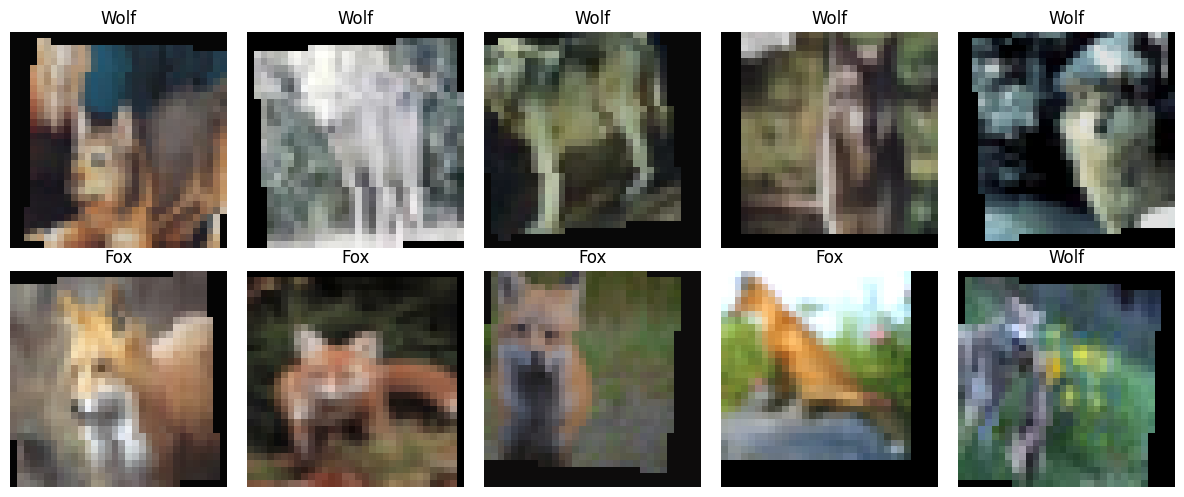

In [ ]:

def denorm(x):
    mean=torch.tensor(MEAN).view(3,1,1); std=torch.tensor(STD).view(3,1,1)
    return (x.cpu()*std+mean).clamp(0,1)

images,labels=next(iter(train_loader))
fig,axs=plt.subplots(2,5,figsize=(12,5))
for ax,img,label in zip(axs.flat,images[:10],labels[:10]):
    ax.imshow(denorm(img).permute(1,2,0)); ax.set_title(CLASS_NAMES[label]); ax.axis('off')
plt.tight_layout(); plt.show()


## 5. Models

In [ ]:

class SimpleCNN(nn.Module):
    def __init__(self,num_classes=2):
        super().__init__()
        self.features=nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),nn.ReLU(),nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1),nn.ReLU(),nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1),nn.ReLU(),nn.MaxPool2d(2))
        self.classifier=nn.Sequential(nn.Flatten(),nn.Linear(128*4*4,128),nn.ReLU(),nn.Dropout(0.5),nn.Linear(128,num_classes))
    def forward(self,x): return self.classifier(self.features(x))

def make_resnet18(num_classes=2):
    m=models.resnet18(weights=None)
    m.conv1=nn.Conv2d(3,64,3,stride=1,padding=1,bias=False)
    m.maxpool=nn.Identity()
    m.fc=nn.Linear(m.fc.in_features,num_classes)
    return m


## 6. Training utilities

In [ ]:

def epoch_pass(model,loader,criterion,optimizer=None):
    training=optimizer is not None
    model.train() if training else model.eval()
    total_loss=0; ys=[]; ps=[]
    context=torch.enable_grad() if training else torch.no_grad()
    with context:
        for x,y in loader:
            x=x.to(device); y=y.to(device)
            if training: optimizer.zero_grad(set_to_none=True)
            out=model(x); loss=criterion(out,y)
            if training: loss.backward(); optimizer.step()
            total_loss+=loss.item()*x.size(0)
            ys.extend(y.cpu().tolist()); ps.extend(out.argmax(1).cpu().tolist())
    return total_loss/len(loader.dataset),accuracy_score(ys,ps)

def train_model(model,path):
    criterion=nn.CrossEntropyLoss(); opt=torch.optim.Adam(model.parameters(),lr=LEARNING_RATE)
    hist={'train_loss':[],'val_loss':[],'train_acc':[],'val_acc':[]}
    best=-1; wait=0
    for e in range(1,EPOCHS+1):
        tl,ta=epoch_pass(model,train_loader,criterion,opt)
        vl,va=epoch_pass(model,val_loader,criterion)
        for k,v in [('train_loss',tl),('val_loss',vl),('train_acc',ta),('val_acc',va)]: hist[k].append(v)
        print(f'Epoch {e:02d}: train={ta:.3f}, val={va:.3f}')
        if va>best:
            best=va; wait=0
            torch.save({'epoch':e,'model_state_dict':model.state_dict(),'best_validation_accuracy':best,'history':hist},path)
        else: wait+=1
        if wait>=PATIENCE:
            print('Early stopping'); break
    ckpt=torch.load(path,map_location=device); model.load_state_dict(ckpt['model_state_dict'])
    print('Best epoch:',ckpt['epoch'],'Best val:',ckpt['best_validation_accuracy'])
    return model,ckpt['history']

def plot_history(hist,title):
    ep=range(1,len(hist['train_loss'])+1)
    plt.figure(figsize=(7,5)); plt.plot(ep,hist['train_loss'],label='Train'); plt.plot(ep,hist['val_loss'],label='Validation'); plt.title(title+' Loss'); plt.xlabel('Epoch'); plt.legend(); plt.grid(alpha=.3); plt.show()
    plt.figure(figsize=(7,5)); plt.plot(ep,hist['train_acc'],label='Train'); plt.plot(ep,hist['val_acc'],label='Validation'); plt.title(title+' Accuracy'); plt.xlabel('Epoch'); plt.legend(); plt.grid(alpha=.3); plt.show()


## 7. Train augmented Simple CNN

Epoch 01: train=0.613, val=0.760
Epoch 02: train=0.733, val=0.800
Epoch 03: train=0.761, val=0.805
Epoch 04: train=0.791, val=0.780
Epoch 05: train=0.791, val=0.830
Epoch 06: train=0.819, val=0.830
Epoch 07: train=0.821, val=0.840
Epoch 08: train=0.800, val=0.820
Epoch 09: train=0.828, val=0.840
Epoch 10: train=0.825, val=0.845
Epoch 11: train=0.846, val=0.855
Epoch 12: train=0.844, val=0.870
Epoch 13: train=0.869, val=0.870
Epoch 14: train=0.868, val=0.885
Epoch 15: train=0.854, val=0.880
Epoch 16: train=0.850, val=0.860
Epoch 17: train=0.853, val=0.890
Epoch 18: train=0.866, val=0.900
Epoch 19: train=0.864, val=0.870
Epoch 20: train=0.877, val=0.885
Epoch 21: train=0.889, val=0.915
Epoch 22: train=0.884, val=0.895
Epoch 23: train=0.895, val=0.895
Epoch 24: train=0.889, val=0.905
Epoch 25: train=0.884, val=0.890
Epoch 26: train=0.894, val=0.890
Epoch 27: train=0.899, val=0.890
Epoch 28: train=0.891, val=0.880
Early stopping
Best epoch: 21 Best val: 0.915


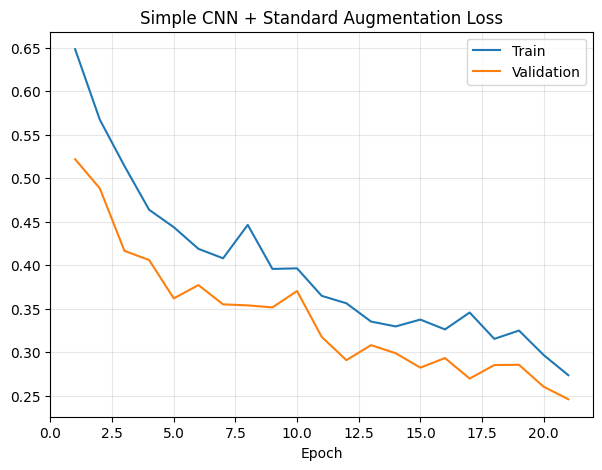

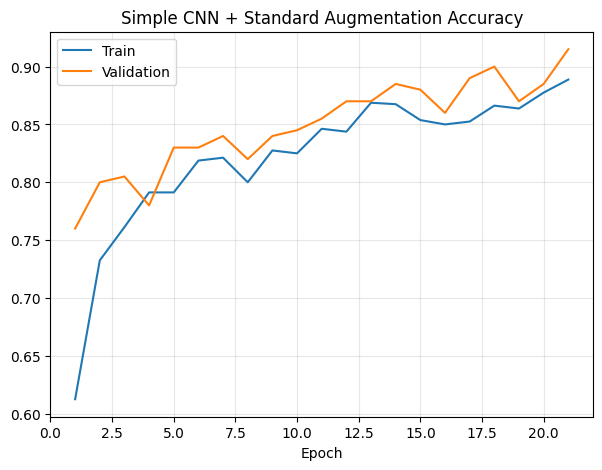

In [ ]:

cnn_aug,hist_cnn=train_model(SimpleCNN().to(device),CNN_AUG_CHECKPOINT)
plot_history(hist_cnn,'Simple CNN + Standard Augmentation')


## 8. Train augmented ResNet18

Epoch 01: train=0.641, val=0.685
Epoch 02: train=0.750, val=0.800
Epoch 03: train=0.771, val=0.685
Epoch 04: train=0.782, val=0.830
Epoch 05: train=0.801, val=0.740
Epoch 06: train=0.824, val=0.865
Epoch 07: train=0.826, val=0.785
Epoch 08: train=0.834, val=0.830
Epoch 09: train=0.863, val=0.865
Epoch 10: train=0.854, val=0.755
Epoch 11: train=0.838, val=0.875
Epoch 12: train=0.874, val=0.875
Epoch 13: train=0.873, val=0.880
Epoch 14: train=0.890, val=0.875
Epoch 15: train=0.876, val=0.870
Epoch 16: train=0.876, val=0.860
Epoch 17: train=0.894, val=0.845
Epoch 18: train=0.904, val=0.845
Epoch 19: train=0.897, val=0.805
Epoch 20: train=0.870, val=0.855
Early stopping
Best epoch: 13 Best val: 0.88


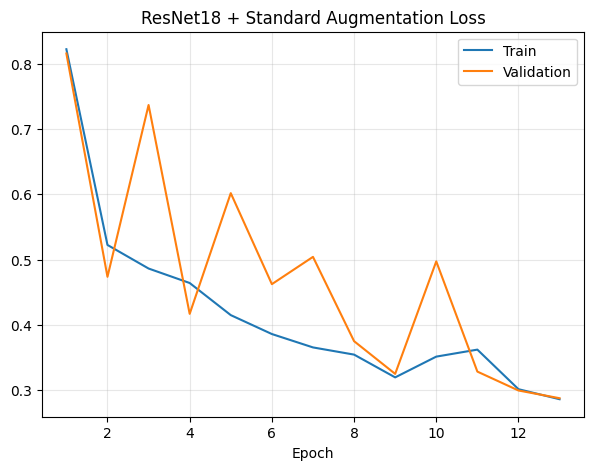

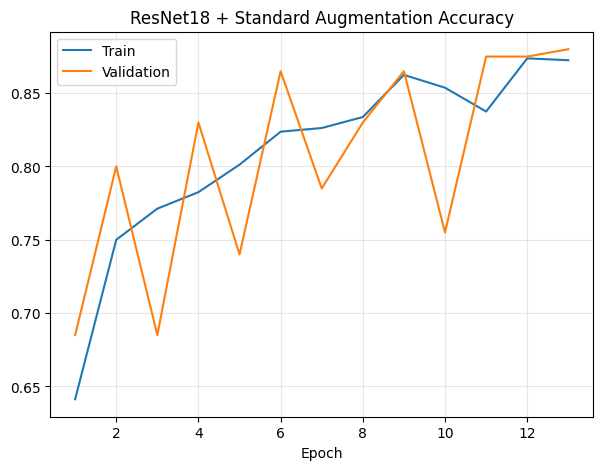

In [ ]:

resnet_aug,hist_resnet=train_model(make_resnet18().to(device),RESNET_AUG_CHECKPOINT)
plot_history(hist_resnet,'ResNet18 + Standard Augmentation')


## 9. Clean evaluation

In [ ]:

@torch.no_grad()
def predict(model,loader,occlusion=None):
    model.eval(); ys=[]; ps=[]
    for x,y in loader:
        x=x.to(device)
        if occlusion is not None: x=apply_occlusion(x,**occlusion)
        p=model(x).argmax(1).cpu()
        ys.extend(y.tolist()); ps.extend(p.tolist())
    return np.array(ys),np.array(ps)

def metrics(model,name,occlusion=None):
    y,p=predict(model,test_loader,occlusion)
    pr,re,f1,_=precision_recall_fscore_support(y,p,average='macro',zero_division=0)
    return {'Model':name,'Accuracy':accuracy_score(y,p),'Macro Precision':pr,'Macro Recall':re,'Macro F1':f1}

clean_df=pd.DataFrame([
    metrics(cnn_aug,'Simple CNN + Standard Augmentation'),
    metrics(resnet_aug,'ResNet18 + Standard Augmentation')])
clean_df


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Simple CNN + Standard Augmentation,0.93,0.932770,0.93,0.929888
1,ResNet18 + Standard Augmentation,0.89,0.890156,0.89,0.889989


In [ ]:

for model,name in [(cnn_aug,'CNN + Augmentation'),(resnet_aug,'ResNet18 + Augmentation')]:
    y,p=predict(model,test_loader)
    print('',name)
    print(classification_report(y,p,target_names=CLASS_NAMES,digits=3,zero_division=0))


 CNN + Augmentation
              precision    recall  f1-score   support

         Fox      0.967     0.890     0.927       100
        Wolf      0.898     0.970     0.933       100

    accuracy                          0.930       200
   macro avg      0.933     0.930     0.930       200
weighted avg      0.933     0.930     0.930       200

 ResNet18 + Augmentation
              precision    recall  f1-score   support

         Fox      0.898     0.880     0.889       100
        Wolf      0.882     0.900     0.891       100

    accuracy                          0.890       200
   macro avg      0.890     0.890     0.890       200
weighted avg      0.890     0.890     0.890       200



## 10. Occlusion evaluation

In [ ]:

def apply_occlusion(images,size,location='center',fill_value=0.0):
    if size==0: return images.clone()
    z=images.clone(); b,_,h,w=z.shape; size=min(size,h,w)
    for i in range(b):
        if location=='center': top=(h-size)//2; left=(w-size)//2
        elif location=='top_left': top,left=0,0
        elif location=='top_right': top,left=0,w-size
        elif location=='bottom_left': top,left=h-size,0
        elif location=='bottom_right': top,left=h-size,w-size
        elif location=='random':
            top=torch.randint(0,h-size+1,(1,)).item(); left=torch.randint(0,w-size+1,(1,)).item()
        else: raise ValueError(location)
        z[i,:,top:top+size,left:left+size]=fill_value
    return z


### 10.1 Increasing center-occlusion size

In [ ]:

sizes=[0,4,8,12,16,20,24]
rows=[]
for model,name in [(cnn_aug,'CNN + Augmentation'),(resnet_aug,'ResNet18 + Augmentation')]:
    for s in sizes:
        r=metrics(model,name,{'size':s,'location':'center'}); r['Occlusion Size']=s; rows.append(r)
size_df=pd.DataFrame(rows)
size_df


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Occlusion Size
0,CNN + Augmentation,0.930,0.932770,0.930,0.929888,0
1,CNN + Augmentation,0.920,0.926136,0.920,0.919711,4
2,CNN + Augmentation,0.895,0.904092,0.895,0.894406,8
3,CNN + Augmentation,0.835,0.861342,0.835,0.831937,12
4,CNN + Augmentation,0.740,0.820000,0.740,0.722667,16
5,CNN + Augmentation,0.590,0.729826,0.590,0.516452,20
6,CNN + Augmentation,0.525,0.645433,0.525,0.400990,24
7,ResNet18 + Augmentation,0.890,0.890156,0.890,0.889989,0
8,ResNet18 + Augmentation,0.880,0.880609,0.880,0.879952,4
9,ResNet18 + Augmentation,0.835,0.842711,0.835,0.834067,8


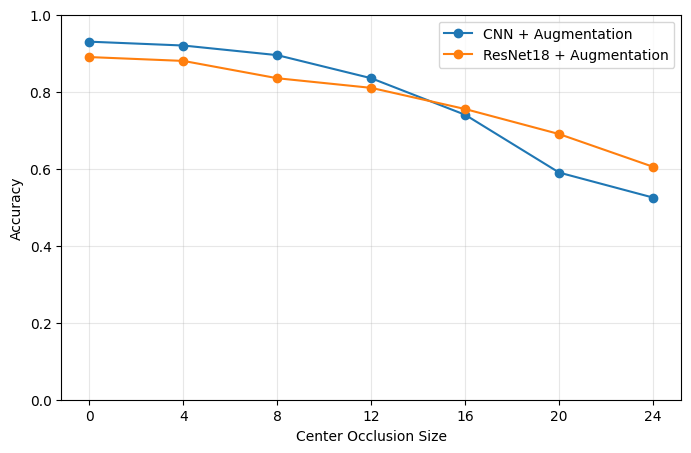

,Model,Occlusion Size,Accuracy Drop
0,CNN + Augmentation,0,0.000
1,CNN + Augmentation,4,0.010
2,CNN + Augmentation,8,0.035
3,CNN + Augmentation,12,0.095
4,CNN + Augmentation,16,0.190
5,CNN + Augmentation,20,0.340
6,CNN + Augmentation,24,0.405
7,ResNet18 + Augmentation,0,0.000
8,ResNet18 + Augmentation,4,0.010
9,ResNet18 + Augmentation,8,0.055


In [ ]:

plt.figure(figsize=(8,5))
for name,g in size_df.groupby('Model'):
    plt.plot(g['Occlusion Size'],g['Accuracy'],marker='o',label=name)
plt.xlabel('Center Occlusion Size'); plt.ylabel('Accuracy'); plt.ylim(0,1); plt.xticks(sizes); plt.grid(alpha=.3); plt.legend(); plt.show()

loss_rows=[]
for name,g in size_df.groupby('Model'):
    clean=g.loc[g['Occlusion Size']==0,'Accuracy'].iloc[0]
    for _,r in g.iterrows(): loss_rows.append({'Model':name,'Occlusion Size':r['Occlusion Size'],'Accuracy Drop':clean-r['Accuracy']})
loss_df=pd.DataFrame(loss_rows)
loss_df


### 10.2 Occlusion location

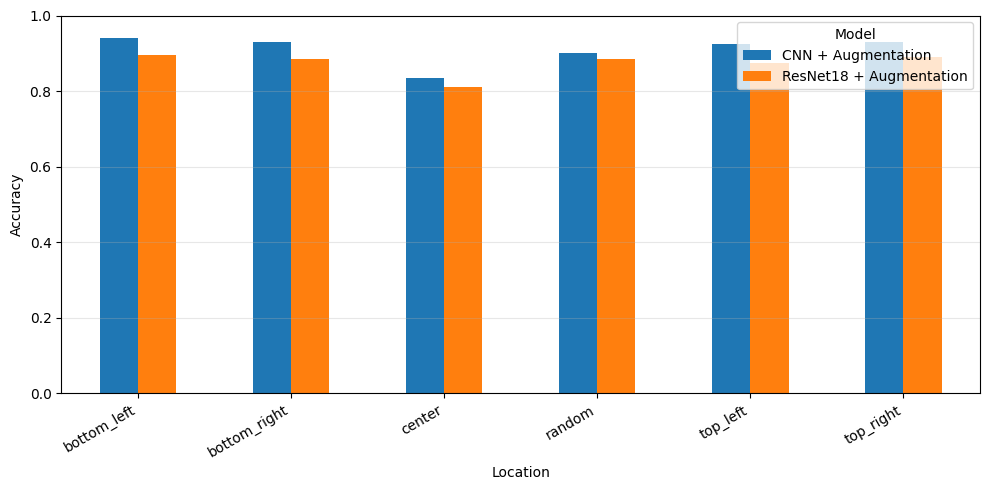

In [ ]:

locations=['top_left','top_right','center','bottom_left','bottom_right','random']
rows=[]
for model,name in [(cnn_aug,'CNN + Augmentation'),(resnet_aug,'ResNet18 + Augmentation')]:
    for loc in locations:
        torch.manual_seed(SEED)
        r=metrics(model,name,{'size':12,'location':loc}); r['Location']=loc; rows.append(r)
location_df=pd.DataFrame(rows)
location_df.pivot(index='Location',columns='Model',values='Accuracy').plot(kind='bar',figsize=(10,5))
plt.ylabel('Accuracy'); plt.ylim(0,1); plt.xticks(rotation=30,ha='right'); plt.grid(axis='y',alpha=.3); plt.tight_layout(); plt.show()


### 10.3 Class-wise results under 16×16 center occlusion

 CNN + Augmentation
              precision    recall  f1-score   support

         Fox      0.980     0.490     0.653       100
        Wolf      0.660     0.990     0.792       100

    accuracy                          0.740       200
   macro avg      0.820     0.740     0.723       200
weighted avg      0.820     0.740     0.723       200



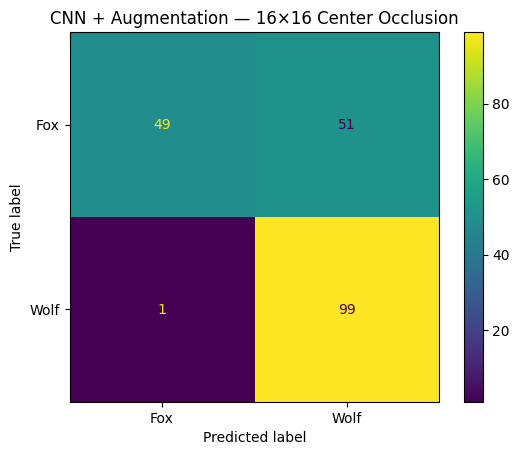

 ResNet18 + Augmentation
              precision    recall  f1-score   support

         Fox      0.918     0.560     0.696       100
        Wolf      0.683     0.950     0.795       100

    accuracy                          0.755       200
   macro avg      0.801     0.755     0.745       200
weighted avg      0.801     0.755     0.745       200



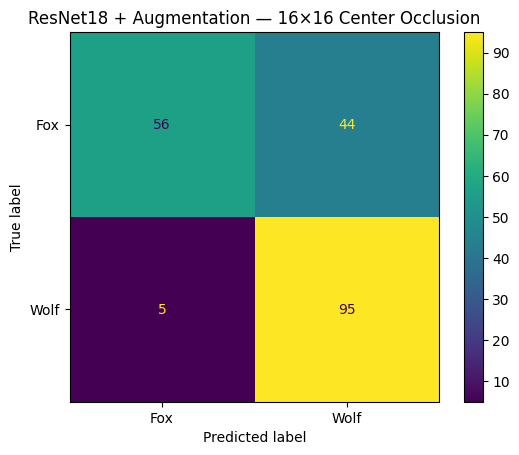

In [ ]:

for model,name in [(cnn_aug,'CNN + Augmentation'),(resnet_aug,'ResNet18 + Augmentation')]:
    y,p=predict(model,test_loader,{'size':16,'location':'center'})
    print('',name)
    print(classification_report(y,p,target_names=CLASS_NAMES,digits=3,zero_division=0))
    ConfusionMatrixDisplay(confusion_matrix(y,p),display_labels=CLASS_NAMES).plot(values_format='d')
    plt.title(name+' — 16×16 Center Occlusion'); plt.show()


## 11. Optional direct comparison with original baseline checkpoints

In [ ]:

def load_model(model,path):
    ckpt=torch.load(path,map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    return model

models_to_compare={
    'CNN + Standard Augmentation':cnn_aug,
    'ResNet18 + Standard Augmentation':resnet_aug,
}
if CNN_BASELINE_CHECKPOINT.exists(): models_to_compare['CNN - No Augmentation']=load_model(SimpleCNN().to(device),CNN_BASELINE_CHECKPOINT)
if RESNET_BASELINE_CHECKPOINT.exists(): models_to_compare['ResNet18 - No Augmentation']=load_model(make_resnet18().to(device),RESNET_BASELINE_CHECKPOINT)
print(list(models_to_compare))


['CNN + Standard Augmentation', 'ResNet18 + Standard Augmentation']


In [ ]:

comparison=[]
for name,model in models_to_compare.items():
    clean=metrics(model,name)['Accuracy']
    row={'Model':name,'Clean Accuracy':clean}
    for s in [12,16,20]:
        acc=metrics(model,name,{'size':s,'location':'center'})['Accuracy']
        row[f'Accuracy {s}×{s}']=acc; row[f'Drop {s}×{s}']=clean-acc
    comparison.append(row)
comparison_df=pd.DataFrame(comparison)
comparison_df


,Model,Clean Accuracy,Accuracy 12×12,Drop 12×12,Accuracy 16×16,Drop 16×16,Accuracy 20×20,Drop 20×20
0,CNN + Standard Augmentation,0.93,0.835,0.095,0.740,0.190,0.59,0.34
1,ResNet18 + Standard Augmentation,0.89,0.810,0.080,0.755,0.135,0.69,0.20


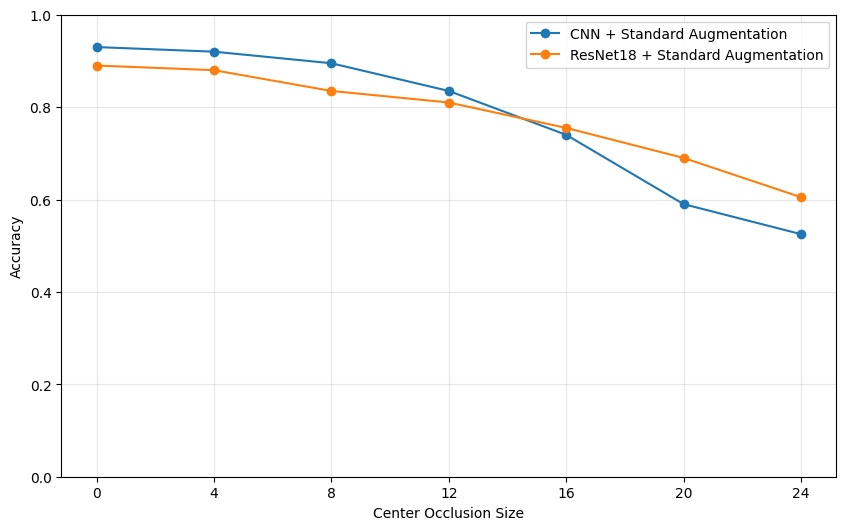

In [ ]:

all_rows=[]
for name,model in models_to_compare.items():
    for s in sizes:
        all_rows.append({'Model':name,'Occlusion Size':s,'Accuracy':metrics(model,name,{'size':s,'location':'center'})['Accuracy']})
all_df=pd.DataFrame(all_rows)
plt.figure(figsize=(10,6))
for name,g in all_df.groupby('Model'):
    plt.plot(g['Occlusion Size'],g['Accuracy'],marker='o',label=name)
plt.xlabel('Center Occlusion Size'); plt.ylabel('Accuracy'); plt.ylim(0,1); plt.xticks(sizes); plt.grid(alpha=.3); plt.legend(); plt.show()


## 12. Save results

In [ ]:

clean_df.to_csv(RESULTS_DIR/'clean_augmented.csv',index=False)
size_df.to_csv(RESULTS_DIR/'occlusion_size_augmented.csv',index=False)
loss_df.to_csv(RESULTS_DIR/'accuracy_drop_augmented.csv',index=False)
location_df.to_csv(RESULTS_DIR/'occlusion_location_augmented.csv',index=False)
comparison_df.to_csv(RESULTS_DIR/'baseline_vs_augmentation.csv',index=False)
print('Saved to',RESULTS_DIR)


Saved to /content/drive/MyDrive/NMA_Occlusion_Project/experiment_2_results


# Results and Discussion: Standard Data Augmentation

## Training Performance

Standard data augmentation improved the training behavior of the Simple CNN. The best validation accuracy increased from approximately **88.5%** in the baseline experiment to **91.5%** after augmentation, indicating that the model generalized better to unseen validation images. The training and validation loss curves decreased steadily without evidence of severe overfitting, suggesting that augmentation acted as an effective regularizer.

For ResNet18, standard augmentation produced a best validation accuracy of approximately **88%**, which was comparable to the baseline model. This indicates that the deeper residual architecture already generalized well, leaving less room for improvement from standard image transformations.

---

## Clean Test Performance

The augmented models achieved the following clean test accuracies:

| Model | Clean Accuracy |
|--------|---------------:|
| CNN + Standard Augmentation | **93.0%** |
| ResNet18 + Standard Augmentation | **89.0%** |

The augmented CNN achieved the highest clean-image accuracy among the two models.

---

## Effect of Occlusion Size

Both models experienced decreasing accuracy as the center occlusion size increased.

| Occlusion Size | CNN + Augmentation | ResNet18 + Augmentation |
|---------------:|-------------------:|------------------------:|
| 0×0 | 0.930 | 0.890 |
| 4×4 | 0.920 | 0.880 |
| 8×8 | 0.895 | 0.835 |
| 12×12 | 0.835 | 0.810 |
| 16×16 | 0.740 | 0.755 |
| 20×20 | 0.590 | 0.690 |
| 24×24 | 0.525 | 0.605 |

The CNN achieved higher accuracy under mild occlusion (0–12 pixels). However, once the occlusion became more severe (16 pixels and above), ResNet18 consistently outperformed the CNN.

This suggests that although the augmented CNN learned strong discriminative features for clean images, the residual architecture remained more robust when substantial portions of the object were hidden.

---

## Accuracy Drop

The reduction in accuracy relative to each model's clean performance is summarized below.

| Occlusion Size | CNN Drop | ResNet18 Drop |
|---------------:|---------:|--------------:|
| 12×12 | 9.5% | 8.0% |
| 16×16 | 19.0% | 13.5% |
| 20×20 | 34.0% | 20.0% |
| 24×24 | 40.5% | 28.5% |

ResNet18 experienced a substantially smaller degradation under severe occlusion, demonstrating greater robustness despite having a lower clean-image accuracy.

---

## Effect of Occlusion Location

Occlusion location also influenced model performance.

The highest accuracies were obtained when occlusions were placed near the image corners, whereas center occlusion consistently produced the largest reduction in accuracy.

This indicates that both models rely primarily on the central visual features of the animal, which contain the most discriminative information.

---

## Class-wise Performance under 16×16 Center Occlusion

### CNN + Standard Augmentation

- Accuracy: **74.0%**
- Fox Recall: **49%**
- Wolf Recall: **99%**

Confusion matrix:

| True Class | Predicted Fox | Predicted Wolf |
|------------|--------------:|---------------:|
| Fox | 49 | 51 |
| Wolf | 1 | 99 |

The CNN continued to exhibit a strong bias toward predicting the **Wolf** class under severe occlusion. More than half of the occluded fox images were misclassified.

---

### ResNet18 + Standard Augmentation

- Accuracy: **75.5%**
- Fox Recall: **56%**
- Wolf Recall: **95%**

Confusion matrix:

| True Class | Predicted Fox | Predicted Wolf |
|------------|--------------:|---------------:|
| Fox | 56 | 44 |
| Wolf | 5 | 95 |

Although ResNet18 also showed reduced performance under severe occlusion, it preserved a higher recall for the Fox class than the CNN, indicating a more balanced use of visual features.

---

# Conclusions

The results indicate that standard data augmentation successfully improved the generalization ability of the Simple CNN, increasing its clean-image accuracy from approximately **90.5%** in the baseline experiment to **93.0%**. The CNN also became more robust to moderate occlusion.

However, under severe occlusion, ResNet18 remained the more robust architecture. Its residual connections likely encouraged the network to learn more distributed feature representations, reducing its dependence on any single image region.

Overall, the experiments suggest that:

- Standard augmentation improves the generalization performance of the Simple CNN.
- Standard augmentation provides limited additional benefit for ResNet18.
- ResNet18 remains the most robust architecture when large portions of the image are occluded.
- Higher clean-image accuracy does not necessarily imply greater robustness to severe occlusion.

<!--
## 13. Interpretation Questions

1. Does standard augmentation improve clean accuracy for each model?
2. Does it reduce the clean-to-occluded accuracy drop?
3. Which model benefits most from augmentation?
4. Is center occlusion still more damaging than corner occlusion?
5. Are fox and wolf recall improved equally?
6. Does the model with the best clean accuracy also preserve the most performance under occlusion?

The stronger augmentation result is the one with the **smaller accuracy drop relative to its own clean accuracy** under the same occlusion condition. -->


# Interpretation Questions

### 1. Does standard augmentation improve clean accuracy for each model?

**CNN:** Yes. Standard augmentation improved the CNN's clean test accuracy from **90.5%** (baseline) to **93.0%**, indicating that the model generalized better to unseen images.

**ResNet18:** No significant improvement was observed. The clean test accuracy decreased slightly from **89.5%** (baseline) to **89.0%**, suggesting that the ResNet18 architecture already generalized well without standard augmentation.

---

### 2. Does it reduce the clean-to-occluded accuracy drop?

Yes, particularly for the CNN.

| Model | Baseline Drop (16×16) | Augmented Drop (16×16) |
|--------|----------------------:|-----------------------:|
| CNN | 27.5% | **19.0%** |
| ResNet18 | 14.0% | **13.5%** |

The CNN experienced a noticeable reduction in performance degradation after augmentation, while the improvement for ResNet18 was relatively small.

At larger occlusions (20×20 and 24×24), the augmented ResNet18 continued to show a substantially smaller accuracy drop than the augmented CNN.

---

### 3. Which model benefits most from augmentation?

The **Simple CNN** benefited the most.

Compared with its baseline performance, the CNN achieved:

- Higher clean accuracy (+2.5 percentage points)
- Smaller accuracy drop under occlusion
- Improved overall generalization

In contrast, ResNet18 showed only marginal changes after augmentation, suggesting that its residual architecture already learned robust visual representations.

---

### 4. Is center occlusion still more damaging than corner occlusion?

Yes.

Both models maintained high accuracies when occlusions were placed in the image corners, whereas center occlusion consistently produced the largest performance degradation.

This indicates that the most informative visual features are concentrated near the center of the object.

---

### 5. Are fox and wolf recall improved equally?

No.

For both architectures, the **Wolf** class maintained substantially higher recall than the **Fox** class under severe occlusion.

For the 16×16 center occlusion:

| Model | Fox Recall | Wolf Recall |
|--------|-----------:|------------:|
| CNN + Augmentation | 49% | 99% |
| ResNet18 + Augmentation | 56% | 95% |

The models therefore remained more likely to correctly recognize wolves than foxes when important image regions were hidden.

---

### 6. Does the model with the best clean accuracy also preserve the most performance under occlusion?

No.

Although the **augmented CNN** achieved the highest clean accuracy (**93.0%**), it degraded more rapidly as occlusion increased.

The **augmented ResNet18**, despite having a lower clean accuracy (**89.0%**), retained higher accuracy under severe occlusion (16×16, 20×20, and 24×24).

This demonstrates that **higher clean-image accuracy does not necessarily imply greater robustness to occlusion**.

---

# Overall Interpretation

The experiments show that standard data augmentation is particularly beneficial for the Simple CNN, improving both clean-image classification and robustness to moderate occlusion. However, under severe occlusion, the ResNet18 architecture remains the more robust model because it experiences a smaller loss in performance as increasingly large portions of the image are hidden. These results suggest that standard augmentation primarily improves generalization for simpler architectures, while the residual learning mechanism of ResNet18 inherently provides stronger robustness to missing visual information.